# Project 3. High Value Client Prediction

## Project Goal

The goal of this project is to build a simple machine learning model that predicts whether a client belongs to the high-value segment based on client characteristics and purchasing behavior.

## Dataset Description

The dataset contains information about clients, their purchasing behavior, and support interactions.

- `client_id` — unique client identifier
- `age` — client age
- `town` — client town
- `orders_count` — number of orders made by the client
- `total_amount` — total purchase amount
- `avg_order_amount` — average order amount
- `days_since_last_order` — number of days since the last order
- `complaints_count` — number of complaints from the client
- `support_messages_count` — number of support messages
- `is_high_value` — target variable: 1 if the client is high value, 0 otherwise

## Import Libraries

In [641]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


## Create Dataset

In [642]:
data = {
    "client_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                  11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    
    "age": [25, 34, 45, 29, 52, 41, 38, 31, 27, 48,
            36, 55, 23, 44, 39, 30, 50, 28, 46, 33],
    
    "town": ["Moscow", "Kazan", "Moscow", "Samara", "Kazan",
             "Moscow", "Samara", "Kazan", "Moscow", "Samara",
             "Kazan", "Moscow", "Samara", "Kazan", "Moscow",
             "Samara", "Kazan", "Moscow", "Samara", "Kazan"],
    
    "orders_count": [2, 8, 10, 1, 12, 7, 3, 9, 2, 4,
                     11, 1, 2, 13, 6, 3, 10, 2, 5, 9],
    
    "total_amount": [3500, 24000, 32000, 1200, 45000,
                     18000, 6000, 27000, 2500, 8000,
                     39000, 1500, 3000, 52000, 16000,
                     5000, 34000, 2800, 11000, 26000],
    
    "avg_order_amount": [1750, 3000, 3200, 1200, 3750,
                         2571, 2000, 3000, 1250, 2000,
                         3545, 1500, 1500, 4000, 2667,
                         1667, 3400, 1400, 2200, 2889],
    
    "days_since_last_order": [45, 7, 5, 90, 3,
                              12, 60, 8, 75, 40,
                              4, 120, 80, 2, 14,
                              55, 6, 70, 35, 9],
    
    "complaints_count": [1, 0, 0, 2, 0,
                         1, 2, 0, 1, 1,
                         0, 3, 2, 0, 1,
                         2, 0, 1, 1, 0],
    
    "support_messages_count": [2, 1, 1, 4, 0,
                               2, 5, 1, 3, 3,
                               1, 6, 4, 0, 2,
                               5, 1, 3, 2, 1],
    
    "is_high_value": [0, 1, 1, 0, 1,
                      1, 0, 1, 0, 0,
                      1, 0, 0, 1, 1,
                      0, 1, 0, 0, 1]
}

df = pd.DataFrame(data)

## Initial Data Review

In [643]:
df.head()

,client_id,age,town,orders_count,total_amount,avg_order_amount,days_since_last_order,complaints_count,support_messages_count,is_high_value
0,1,25,Moscow,2,3500,1750,45,1,2,0
1,2,34,Kazan,8,24000,3000,7,0,1,1
2,3,45,Moscow,10,32000,3200,5,0,1,1
3,4,29,Samara,1,1200,1200,90,2,4,0
4,5,52,Kazan,12,45000,3750,3,0,0,1


In [644]:
df.shape

(20, 10)

In [645]:
df.columns

Index(['client_id', 'age', 'town', 'orders_count', 'total_amount',
       'avg_order_amount', 'days_since_last_order', 'complaints_count',
       'support_messages_count', 'is_high_value'],
      dtype='object')

In [646]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   client_id               20 non-null     int64 
 1   age                     20 non-null     int64 
 2   town                    20 non-null     object
 3   orders_count            20 non-null     int64 
 4   total_amount            20 non-null     int64 
 5   avg_order_amount        20 non-null     int64 
 6   days_since_last_order   20 non-null     int64 
 7   complaints_count        20 non-null     int64 
 8   support_messages_count  20 non-null     int64 
 9   is_high_value           20 non-null     int64 
dtypes: int64(9), object(1)
memory usage: 1.7+ KB


In [647]:
df.isna().sum()

client_id                 0
age                       0
town                      0
orders_count              0
total_amount              0
avg_order_amount          0
days_since_last_order     0
complaints_count          0
support_messages_count    0
is_high_value             0
dtype: int64

In [648]:
df["is_high_value"].value_counts()

is_high_value
0    10
1    10
Name: count, dtype: int64

In [649]:
df["is_high_value"].value_counts(normalize=True)

is_high_value
0    0.5
1    0.5
Name: proportion, dtype: float64

## Prepare Features and Target

In [650]:
x_columns = [
  "age", 
  "town", 
  "orders_count", 
  "total_amount", 
  "avg_order_amount", 
  "days_since_last_order", 
  "complaints_count", 
  "support_messages_count"
]

x_table = df[x_columns].copy()
y_table = df["is_high_value"]

x_table = pd.get_dummies(
  x_table,
  columns=["town"],
  dtype=int
)

In [651]:
x_table.head()

,age,orders_count,total_amount,avg_order_amount,days_since_last_order,complaints_count,support_messages_count,town_Kazan,town_Moscow,town_Samara
0,25,2,3500,1750,45,1,2,0,1,0
1,34,8,24000,3000,7,0,1,1,0,0
2,45,10,32000,3200,5,0,1,0,1,0
3,29,1,1200,1200,90,2,4,0,0,1
4,52,12,45000,3750,3,0,0,1,0,0


In [652]:
x_table.shape

(20, 10)

In [653]:
y_table.head()

0    0
1    1
2    1
3    0
4    1
Name: is_high_value, dtype: int64

In [654]:
text_columns = x_table.select_dtypes(include=["object", "string", "category"]).columns

text_columns

Index([], dtype='object')

## Train/Test Split

In [655]:
X_train, X_test, y_train, y_test = train_test_split(
  x_table,
  y_table,
  test_size=0.3,
  random_state=42
)

In [656]:
X_train.shape

(14, 10)

In [657]:
X_test.shape

(6, 10)

In [658]:
y_train.shape

(14,)

In [659]:
y_test.shape

(6,)

## Train the Decision Tree Model

In [660]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred

array([0, 0, 0, 1, 0, 1])

In [661]:
y_test

0     0
17    0
15    0
1     1
8     0
5     1
Name: is_high_value, dtype: int64

## Model Evaluation

In [662]:
model_metrics = pd.DataFrame({
  "metric": [
    "accuracy", 
    "precision", 
    "recall", 
    "f1_score"
  ],
  "value": [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
  ]
})

model_metrics

,metric,value
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1_score,1.0


## Model Evaluation Conclusion

On the test set, the model predictions fully matched the actual values. All calculated metrics are equal to 1.0.

However, the test set contains only 6 clients, so this result should not be considered proof of perfect model quality. With such a small dataset, the metrics may be unstable. A larger dataset is required for a more reliable evaluation.

## Decision Tree with Limited Depth

In [663]:
limited_model = DecisionTreeClassifier(max_depth=2, random_state=42)
limited_model.fit(X_train, y_train)

limited_y_pred = limited_model.predict(X_test)

limited_y_pred

array([0, 0, 0, 1, 0, 1])

In [664]:
comparative_models_table = pd.DataFrame({
  "metric": [
    "accuracy", 
    "precision", 
    "recall", 
    "f1_score"
  ],
  "unlimited_model": [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
  ], 
  "limited_model": [
    accuracy_score(y_test, limited_y_pred),
    precision_score(y_test, limited_y_pred),
    recall_score(y_test, limited_y_pred),
    f1_score(y_test, limited_y_pred)
  ]
})

comparative_models_table

,metric,unlimited_model,limited_model
0,accuracy,1.0,1.0
1,precision,1.0,1.0
2,recall,1.0,1.0
3,f1_score,1.0,1.0


## Decision Tree with Limited Depth Conclusion

The limited-depth decision tree was trained with `max_depth=2`.

This model is simpler than the original decision tree and may reduce the risk of overfitting. In this case, both the original decision tree and the limited-depth decision tree achieved the same metric values on the small test set.

However, the dataset contains only 20 clients and the test set contains only 6 clients, so this comparison should be interpreted with caution.

Comparing the original model and the limited-depth model helps evaluate whether a simpler tree can achieve similar performance.

## Train and Test Accuracy Comparison

In [665]:
accuracy_comparison = pd.DataFrame({
  "model": [
    "original_model", 
    "limited_depth_model"
  ],
  "train_accuracy": [
    model.score(X_train, y_train), 
    limited_model.score(X_train, y_train)
  ],
  "test_accuracy": [
    model.score(X_test, y_test),
    limited_model.score(X_test, y_test)
  ]
})

accuracy_comparison

,model,train_accuracy,test_accuracy
0,original_model,1.0,1.0
1,limited_depth_model,1.0,1.0


## Train and Test Accuracy Comparison Conclusion

The train and test accuracy comparison helps evaluate whether the models may be overfitting.

In this project, both models achieved the same train and test accuracy values on the current dataset. However, the dataset contains only 20 clients, so the train/test comparison should be interpreted with caution.

A larger dataset would be required to make a more reliable conclusion about overfitting.

## Cross-Validation

In [666]:
original_cv = cross_val_score(model, x_table, y_table, cv=5, scoring='accuracy')
limited_cv = cross_val_score(limited_model, x_table, y_table, cv=5, scoring='accuracy')

cv_table = pd.DataFrame({
  "model": [
    "original_tree", 
    "limited_depth_tree"
  ],
  "mean_cv_accuracy": [
    original_cv.mean(), 
    limited_cv.mean()
  ],
  "std_cv_accuracy": [
    original_cv.std(),
    limited_cv.std()
  ]
})

cv_table

,model,mean_cv_accuracy,std_cv_accuracy
0,original_tree,1.0,0.0
1,limited_depth_tree,1.0,0.0


## Cross-Validation Conclusion

Cross-validation provides a more stable estimate of model performance than a single train/test split.

In this project, cross-validation was used to compare the original decision tree and the limited-depth decision tree. The mean cross-validation accuracy helps compare the average performance of both models across several data splits.

However, the dataset contains only 20 clients, so the cross-validation results should also be interpreted with caution.

A larger dataset would be required to make a more reliable conclusion about model stability.

## Confusion Matrix

In [667]:
conf_matrix = confusion_matrix(y_test, y_pred)

confusion_table = pd.DataFrame(
  conf_matrix,
  columns=["Predicted_0", "Predicted_1"],
  index=["Actual_0", "Actual_1"]
)

confusion_table

,Predicted_0,Predicted_1
Actual_0,4,0
Actual_1,0,2


## Confusion Matrix Conclusion

The confusion matrix shows that the model made no errors on the test set.

There were 4 correctly predicted not high-value clients and 2 correctly predicted high-value clients. The model made no false positive or false negative errors.

Class `0` means not high-value, and class `1` means high-value.

However, the test set contains only 6 clients, so this result should be interpreted with caution.

## Confusion Matrix Visualization

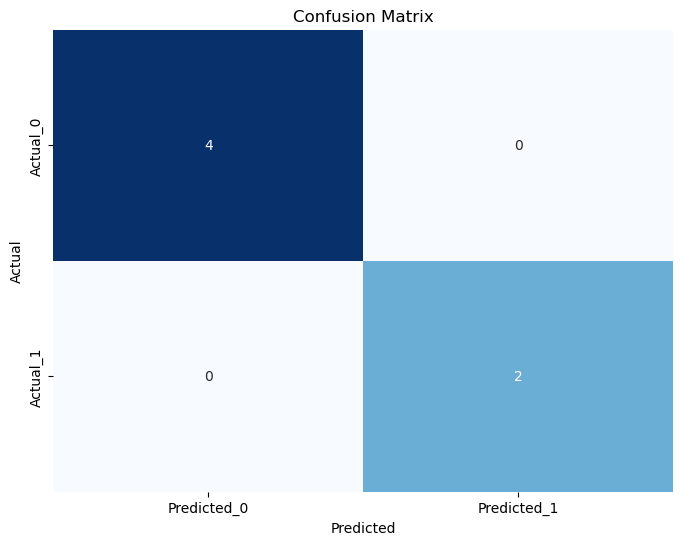

In [668]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix Visualization Conclusion

The heatmap confirms that the model made no errors on the test set. All predictions are located on the main diagonal of the confusion matrix.

There were 4 correctly predicted not high-value clients and 2 correctly predicted high-value clients.

However, the test set contains only 6 clients, so this result should be interpreted with caution.

## Feature Importance

In [669]:
feature_importances = pd.DataFrame({
  "feature": x_table.columns,
  "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances

,feature,importance
2,total_amount,1.0
0,age,0.0
1,orders_count,0.0
3,avg_order_amount,0.0
4,days_since_last_order,0.0
5,complaints_count,0.0
6,support_messages_count,0.0
7,town_Kazan,0.0
8,town_Moscow,0.0
9,town_Samara,0.0


## Feature Importance Conclusion

The feature importance analysis showed that the model relied mainly on one feature — `total_amount`.

This partially matches business logic: clients with a higher total purchase amount are more likely to belong to the high-value segment.

However, the dataset contains only 20 clients, so the feature importance results should not be considered stable. With a larger dataset, the model could also rely on other features, such as `orders_count`, `avg_order_amount`, or `days_since_last_order`.

## Feature Importance Visualization

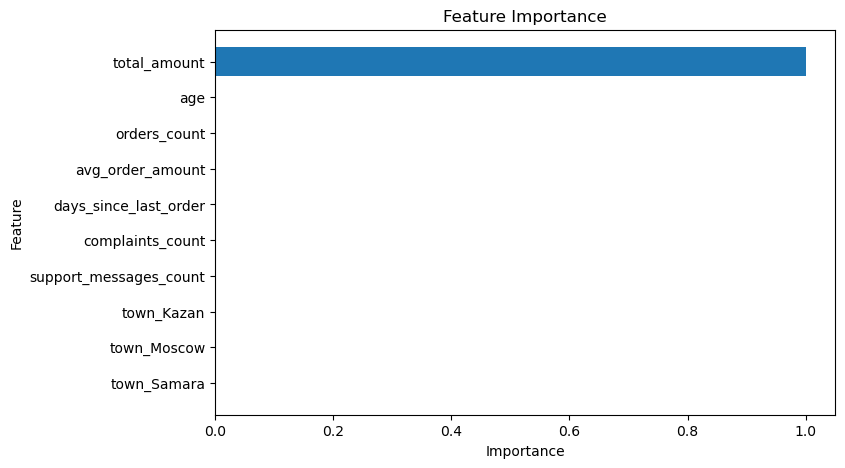

In [670]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importances["feature"],
    feature_importances["importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance Visualization Conclusion

The bar chart confirms that the model mainly relied on `total_amount`.

This result is logical because clients with a higher total purchase amount are more likely to belong to the high-value segment.

However, the dataset contains only 20 clients, so the feature importance results should be interpreted with caution.

## Final Conclusions

In this project, a simple classification model was built to predict whether a client belongs to the high-value segment.

The target variable was `is_high_value`. The model used client characteristics and purchasing behavior indicators as features, including age, town, number of orders, total purchase amount, average order amount, days since the last order, number of complaints, and number of support messages.

The first model was a Decision Tree Classifier. A second decision tree with limited depth was also trained using `max_depth=2` in order to compare the original model with a simpler and more interpretable version.

Both models were evaluated using accuracy, precision, recall, and F1-score. The train and test accuracy comparison was used to check whether the models might be overfitting.

Cross-validation was also applied to compare model performance across several data splits. This provided a more stable evaluation than a single train/test split, although the results should still be interpreted with caution because the dataset is very small.

The confusion matrix and its heatmap showed that the model made no errors on the current test set. However, the test set contains only 6 clients, so this result should not be considered reliable evidence of perfect model quality.

The feature importance analysis showed that the model mainly relied on `total_amount`. This is logical from a business perspective because clients with a higher total purchase amount are more likely to belong to the high-value segment.

The main limitation of this project is the small educational dataset, which contains only 20 clients. Because of this, the results may be unstable and should not be treated as proof of real-world model performance.

In the future, this project could be improved by using a larger real-world dataset, comparing additional machine learning models, tuning hyperparameters, applying more robust validation techniques, and evaluating performance on a larger and more stable test set.